# Deep Learning Cox Model

This notebook implements Part D of the assignment:

1. Define a Deep Cox model where the linear predictor is replaced by a neural network.
2. Use the hazard form $\lambda(t \mid X) = \lambda_0(t) \exp(f_\theta(X))$.
3. Train the network with the Cox partial likelihood.

The notebook is ready to run once you set the dataset path and the relevant column names.

Team protocol note: the locked-down team delivery workflow now lives in `run_team_cox_deep_cox_protocol.py`, which trains on `IR/team_train.parquet` and writes the required six CSV submissions.

## Environment Note

Use the project virtual environment in this folder when you run the notebook. The package list is saved in `requirements-deep-cox.txt`.

In [1]:
from pathlib import Path

import os
import sys

os.environ.setdefault('MPLCONFIGDIR', str(Path('.matplotlib').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from deep_cox_assignment import (
    DeepCox,
    concordance_index,
    estimate_breslow_baseline_hazard,
    fit_classical_cox,
    predict_survival_curves,
    predict_classical_cox_log_risk,
    prepare_classical_cox_splits,
    prepare_survival_splits,
    read_survival_table,
    set_seed,
    split_survival_dataframe,
    to_tensor_frame,
    to_tensor_vector,
    train_deep_cox,
    validate_survival_columns,
)

set_seed(42)

expected_python = (Path('.venv') / 'bin' / 'python').resolve()
active_python = Path(sys.executable).resolve()

print('python executable:', active_python)
print('torch version:', torch.__version__)
print('pandas version:', pd.__version__)

if expected_python.exists() and active_python != expected_python:
    print(
        "WARNING: this notebook is not using the project virtualenv. "
        "Switch the kernel to 'Python (.venv Deep Cox)' to access lifelines and the other project packages."
    )

python executable: /usr/local/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/bin/python3.12
torch version: 2.2.2
pandas version: 2.3.3


## Step 1: Configure The Dataset

The defaults below point to a Freddie Mac Deep Cox dataset built from the 2000 origination and monthly performance files.
The event definition is the first month with `ZeroBalanceCode = 01` (Prepaid or Matured / Voluntary Payoff). Other zero-balance outcomes are treated as censored at their termination month.

Update the file path and column names below if you build another year.

- `TIME_COL`: survival or duration column
- `EVENT_COL`: event indicator with `1 = event` and `0 = censored`
- `FEATURE_COLS = None`: use every remaining column as a feature
- `CATEGORICAL_COLS = None`: infer categorical columns automatically
- `SPLIT_COL`: calendar column used for the chronological train/validation/test split

In [2]:
DATA_PATH = Path('Freddie_Mac_Loan_Data/deep_cox_2000_prepay_only.parquet')
TIME_COL = 'duration_months'
EVENT_COL = 'event'
SPLIT_COL = 'last_reporting_period'

FEATURE_COLS = [
    'CreditScore',
    'FirstTimeHomebuyerFlag',
    'MortgageInsurancePercentage',
    'NumberofUnits',
    'OccupancyStatus',
    'OriginalCombinedLoantoValueCLTV',
    'OriginalDebttoIncomeRatio',
    'OriginalUPB',
    'OriginalLoantoValueLTV',
    'OriginalInterestRate',
    'Channel',
    'PropertyState',
    'PropertyType',
    'LoanPurpose',
    'OriginalLoanTerm',
    'NumberofBorrowers',
]

CATEGORICAL_COLS = [
    'FirstTimeHomebuyerFlag',
    'OccupancyStatus',
    'Channel',
    'PropertyState',
    'PropertyType',
    'LoanPurpose',
]

VAL_SIZE = 0.15
TEST_SIZE = 0.15
SEED = 42

HIDDEN_DIMS = (128, 64, 32)
DROPOUT = 0.05
ACTIVATION = 'gelu'
USE_BATCH_NORM = True
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 150
PATIENCE = 20
CINDEX_EVERY = 5
SELECTION_METRIC = 'cindex'
SELECTION_MIN_DELTA = 1e-4
COMPUTE_TRAIN_CINDEX = False
TIE_METHOD = 'efron'
COX_PENALIZER = 1e-3
COX_L1_RATIO = 0.0

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Update DATA_PATH before running this notebook. File not found: {DATA_PATH.resolve()}'
    )

## Step 2: Load And Validate The Survival Data

In [3]:
df = read_survival_table(DATA_PATH)
feature_cols = validate_survival_columns(df, TIME_COL, EVENT_COL, FEATURE_COLS)

print('Dataset shape:', df.shape)
print('Number of feature columns:', len(feature_cols))
print('Event rate:', float(df[EVENT_COL].mean()))
display(df.head())

Dataset shape: (746368, 25)
Number of feature columns: 16
Event rate: 0.9796253322757674


,LoanSequenceNumber,duration_months,event,zero_balance_code,event_loan_age,event_reporting_period,last_observed_loan_age,last_reporting_period,origination_year,CreditScore,...,OriginalDebttoIncomeRatio,OriginalUPB,OriginalLoantoValueLTV,OriginalInterestRate,Channel,PropertyState,PropertyType,LoanPurpose,OriginalLoanTerm,NumberofBorrowers
0,F00Q10000003,16,1,1.0,16.0,200307.0,16,200307,2000,742.0,...,38.0,112000.0,79.0,7.125,T,WI,SF,N,336,1.0
1,F00Q10000004,9,1,1.0,9.0,200212.0,9,200212,2000,750.0,...,32.0,101000.0,74.0,7.000,T,WI,SF,C,337,2.0
2,F00Q10000005,8,1,1.0,8.0,200211.0,8,200211,2000,762.0,...,27.0,112000.0,54.0,7.000,T,WI,SF,P,336,1.0
3,F00Q10000006,8,1,1.0,8.0,200212.0,8,200212,2000,750.0,...,21.0,188000.0,49.0,7.125,T,WI,SF,P,336,2.0
4,F00Q10000007,26,1,1.0,26.0,200312.0,26,200312,2000,764.0,...,44.0,149000.0,62.0,6.500,R,WI,SF,N,340,2.0


## Step 3: Train, Validation, And Test Splits

The preprocessing step standardizes numeric columns, one-hot encodes categoricals, keeps the feature columns aligned across all splits, and fits a classical Cox benchmark after dropping one reference dummy per categorical variable. The split below is chronological using `SPLIT_COL` rather than a random split.

In [4]:
train_df, val_df, test_df = split_survival_dataframe(
    df=df,
    event_col=EVENT_COL,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=SEED,
    sort_col=SPLIT_COL,
)

print('Chronological split column:', SPLIT_COL)
print('Train period range:', train_df[SPLIT_COL].min(), 'to', train_df[SPLIT_COL].max())
print('Validation period range:', val_df[SPLIT_COL].min(), 'to', val_df[SPLIT_COL].max())
print('Test period range:', test_df[SPLIT_COL].min(), 'to', test_df[SPLIT_COL].max())

prepared = prepare_survival_splits(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    time_col=TIME_COL,
    event_col=EVENT_COL,
    feature_cols=feature_cols,
    categorical_cols=CATEGORICAL_COLS,
)

print('Train shape:', prepared.x_train.shape)
print('Validation shape:', prepared.x_val.shape)
print('Test shape:', prepared.x_test.shape)
print('Numeric columns:', prepared.numeric_columns[:10])
print('Categorical columns:', prepared.categorical_columns[:10])

classical_prepared = prepare_classical_cox_splits(
    x_train=prepared.x_train,
    x_val=prepared.x_val,
    x_test=prepared.x_test,
    categorical_columns=prepared.categorical_columns,
)

print('Classical Cox feature count:', classical_prepared.x_train.shape[1])
print('Dropped reference columns:', classical_prepared.dropped_reference_columns)

classical_cox = fit_classical_cox(
    x_train=classical_prepared.x_train,
    time_train=prepared.t_train,
    event_train=prepared.e_train,
    penalizer=COX_PENALIZER,
    l1_ratio=COX_L1_RATIO,
)

top_classical_cox_coefficients = (
    pd.DataFrame(
        {
            'feature': classical_cox.params_.index,
            'coefficient': classical_cox.params_.to_numpy(),
            'hazard_ratio': np.exp(classical_cox.params_.to_numpy()),
        }
    )
    .assign(abs_coefficient=lambda frame: frame['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
    .drop(columns='abs_coefficient')
)

display(top_classical_cox_coefficients.head(10))

Chronological split column: last_reporting_period
Train period range: 200002 to 200301
Validation period range: 200302 to 200310
Test period range: 200311 to 202509
Train shape: (531205, 84)
Validation shape: (104905, 84)
Test shape: (110258, 84)
Numeric columns: ['CreditScore', 'MortgageInsurancePercentage', 'NumberofUnits', 'OriginalCombinedLoantoValueCLTV', 'OriginalDebttoIncomeRatio', 'OriginalUPB', 'OriginalLoantoValueLTV', 'OriginalInterestRate', 'OriginalLoanTerm', 'NumberofBorrowers']
Categorical columns: ['FirstTimeHomebuyerFlag', 'OccupancyStatus', 'Channel', 'PropertyState', 'PropertyType', 'LoanPurpose']
Classical Cox feature count: 78
Dropped reference columns: ['FirstTimeHomebuyerFlag_N', 'OccupancyStatus_I', 'Channel_B', 'PropertyState_AK', 'PropertyType_CO', 'LoanPurpose_C']


/Users/apple/Desktop/Academics/Interest Rates/.venv/lib/python3.12/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['PropertyState_GU', 'PropertyState_VI'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


,feature,coefficient,hazard_ratio
65,PropertyState_VI,-1.564260,0.209243
68,PropertyState_WI,0.606427,1.833867
11,FirstTimeHomebuyerFlag___missing__,-0.494648,0.609786
28,PropertyState_GU,-0.483706,0.616494
29,PropertyState_HI,-0.420367,0.656806
32,PropertyState_IL,0.412127,1.510027
40,PropertyState_MI,0.394933,1.484285
57,PropertyState_PR,-0.343957,0.708960
42,PropertyState_MO,0.324935,1.383941
75,PropertyType___missing__,0.307993,1.360692


## Step 4: Convert The Data To Tensors

In [5]:
x_train = to_tensor_frame(prepared.x_train)
x_val = to_tensor_frame(prepared.x_val)
x_test = to_tensor_frame(prepared.x_test)

t_train = to_tensor_vector(prepared.t_train)
t_val = to_tensor_vector(prepared.t_val)
t_test = to_tensor_vector(prepared.t_test)

e_train = to_tensor_vector(prepared.e_train)
e_val = to_tensor_vector(prepared.e_val)
e_test = to_tensor_vector(prepared.e_test)

print('Tensor shapes:')
print('x_train:', tuple(x_train.shape))
print('t_train:', tuple(t_train.shape))
print('e_train:', tuple(e_train.shape))

Tensor shapes:
x_train: (531205, 84)
t_train: (531205,)
e_train: (531205,)


## Step 5: Define And Train The Deep Cox Model

The neural network returns a single log-risk score $f_\theta(X)$ for each observation. The training objective is the Cox partial likelihood with Efron handling of tied event times by default.

In [6]:
model = DeepCox(
    input_dim=x_train.shape[1],
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
    activation=ACTIVATION,
    use_batch_norm=USE_BATCH_NORM,
)

model, history = train_deep_cox(
    model=model,
    x_train=x_train,
    t_train=t_train,
    e_train=e_train,
    x_val=x_val,
    t_val=t_val,
    e_val=e_val,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=PATIENCE,
    cindex_every=CINDEX_EVERY,
    selection_metric=SELECTION_METRIC,
    selection_min_delta=SELECTION_MIN_DELTA,
    compute_train_cindex=COMPUTE_TRAIN_CINDEX,
    tie_method=TIE_METHOD,
)

display(history.tail())

Starting Deep Cox training (epochs=150, lr=1.0e-03, weight_decay=1.0e-04, patience=20, cindex_every=5, compute_train_cindex=False, tie_method=efron, selection_metric=cindex, selection_min_delta=1.0e-04, train_rows=531,205, val_rows=104,905, features=84, train_events=527,837, val_events=103,129).
[   1/150] progress=  0.67% train_loss=12.2351 val_loss=10.5650 train_cindex=skipped val_cindex=0.4933 best_val_loss=10.5650 wait=0/20 epoch_time=6.76s elapsed=6.77s
  New best validation C-index at epoch 1: 0.4933
  Validation C-index checkpoint at epoch 1: 0.4933 (best observed: 0.4933)
[  25/150] progress= 16.67% train_loss=12.1409 val_loss=10.5718 train_cindex=skipped val_cindex=0.4915 best_val_loss=10.5650 wait=24/20 epoch_time=4.82s elapsed=99.54s
  Validation C-index checkpoint at epoch 25: 0.4915 (best observed: 0.4933)
Early stopping at epoch 25. Best checkpoint epoch: 1. Best validation loss: 10.5650. Best validation C-index: 0.4933. Total elapsed time: 99.54s.
Finished Deep Cox train

,epoch,train_loss,val_loss,train_cindex,val_cindex,best_val_loss,best_val_cindex,best_epoch,wait,improved,computed_cindex,epoch_seconds,elapsed_seconds
20,21,12.144076,10.570097,NaN,0.481469,10.564986,0.493267,1,20,0,0,3.384411,85.547221
21,22,12.143126,10.570578,NaN,0.481469,10.564986,0.493267,1,21,0,0,3.221362,88.768592
22,23,12.142301,10.571025,NaN,0.481469,10.564986,0.493267,1,22,0,0,2.993357,91.761955
23,24,12.141862,10.571423,NaN,0.481469,10.564986,0.493267,1,23,0,0,2.954423,94.716385
24,25,12.140942,10.571801,NaN,0.491537,10.564986,0.493267,1,24,0,1,4.823463,99.539856


## Step 6: Inspect The Training Curves

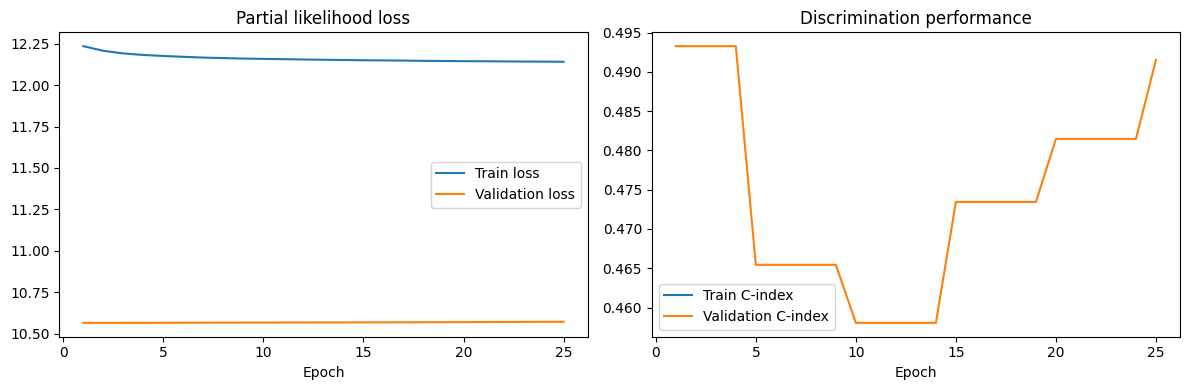

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['epoch'], history['train_loss'], label='Train loss')
axes[0].plot(history['epoch'], history['val_loss'], label='Validation loss')
axes[0].set_title('Partial likelihood loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['epoch'], history['train_cindex'], label='Train C-index')
axes[1].plot(history['epoch'], history['val_cindex'], label='Validation C-index')
axes[1].set_title('Discrimination performance')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 7: Evaluate On The Test Set

In [8]:
model.eval()
with torch.no_grad():
    deep_train_log_risk = model(x_train).cpu().numpy()
    deep_val_log_risk = model(x_val).cpu().numpy()
    deep_test_log_risk = model(x_test).cpu().numpy()

classical_train_log_risk = predict_classical_cox_log_risk(classical_cox, classical_prepared.x_train)
classical_val_log_risk = predict_classical_cox_log_risk(classical_cox, classical_prepared.x_val)
classical_test_log_risk = predict_classical_cox_log_risk(classical_cox, classical_prepared.x_test)

deep_train_cindex = concordance_index(prepared.t_train, prepared.e_train, deep_train_log_risk)
deep_val_cindex = concordance_index(prepared.t_val, prepared.e_val, deep_val_log_risk)
deep_test_cindex = concordance_index(prepared.t_test, prepared.e_test, deep_test_log_risk)

classical_train_cindex = concordance_index(prepared.t_train, prepared.e_train, classical_train_log_risk)
classical_val_cindex = concordance_index(prepared.t_val, prepared.e_val, classical_val_log_risk)
classical_test_cindex = concordance_index(prepared.t_test, prepared.e_test, classical_test_log_risk)

comparison = pd.DataFrame(
    [
        {
            'model': 'Classical Cox',
            'train_cindex': classical_train_cindex,
            'validation_cindex': classical_val_cindex,
            'test_cindex': classical_test_cindex,
        },
        {
            'model': 'Deep Cox',
            'train_cindex': deep_train_cindex,
            'validation_cindex': deep_val_cindex,
            'test_cindex': deep_test_cindex,
        },
    ]
)

display(comparison)

predictions = pd.DataFrame(
    {
        'time': prepared.t_test,
        'event': prepared.e_test,
        'deep_log_risk': deep_test_log_risk,
        'deep_risk_score': np.exp(deep_test_log_risk),
        'classical_log_risk': classical_test_log_risk,
        'classical_risk_score': np.exp(classical_test_log_risk),
    }
)

display(predictions.head())

,model,train_cindex,validation_cindex,test_cindex
0,Classical Cox,0.616661,0.492329,0.536462
1,Deep Cox,0.525269,0.493267,0.503390


,time,event,deep_log_risk,deep_risk_score,classical_log_risk,classical_risk_score
0,23.0,1.0,-0.032141,0.968370,-0.539910,0.582801
1,36.0,1.0,-0.035236,0.965378,0.171319,1.186869
2,44.0,1.0,-0.034931,0.965672,-0.554587,0.574309
3,33.0,1.0,-0.031739,0.968759,-0.186756,0.829646
4,43.0,1.0,-0.034226,0.966354,-0.374872,0.687377


## Step 8: Optional Baseline Hazard And Survival Curves

The Cox model does not learn the baseline hazard directly during training. This cell estimates it afterward with the Breslow estimator so you can produce survival curves.

,time,baseline_hazard,baseline_cumulative_hazard,baseline_survival
0,0.0,0.001510,0.001510,0.998491
1,1.0,0.005604,0.007114,0.992911
2,2.0,0.009804,0.016917,0.983225
3,3.0,0.014689,0.031606,0.968888
4,4.0,0.019616,0.051222,0.950068


,time,sample_0,sample_1,sample_2
0,0.0,0.998539,0.998543,0.998543
1,1.0,0.993135,0.993156,0.993154
2,2.0,0.983751,0.983801,0.983796
3,3.0,0.969857,0.969949,0.969940
4,4.0,0.951608,0.951754,0.951740


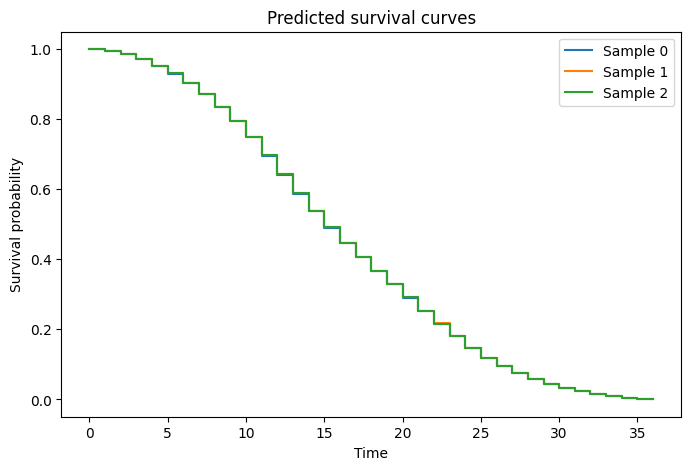

In [9]:
baseline_hazard = estimate_breslow_baseline_hazard(
    time=prepared.t_train,
    event=prepared.e_train,
    log_risk=deep_train_log_risk,
)

curve_indices = list(range(min(3, len(deep_test_log_risk))))
survival_curves = predict_survival_curves(
    baseline_hazard=baseline_hazard,
    log_risk=deep_test_log_risk,
    index=curve_indices,
)

display(baseline_hazard.head())
display(survival_curves.head())

plt.figure(figsize=(8, 5))
for sample_index in curve_indices:
    plt.step(
        survival_curves['time'],
        survival_curves[f'sample_{sample_index}'],
        where='post',
        label=f'Sample {sample_index}',
    )
plt.title('Predicted survival curves')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.legend()
plt.show()

## Step 9: Save The Test Predictions

In [10]:
output_path = Path('deep_cox_test_predictions.csv')
predictions.to_csv(output_path, index=False)
print(f'Saved test predictions to {output_path.resolve()}')

Saved test predictions to /Users/apple/Desktop/Academics/Interest Rates/deep_cox_test_predictions.csv


## Reporting Notes

For the write-up, you can describe the implementation as follows:

- The linear Cox predictor $\beta^\top X$ is replaced by a neural network score $f_\theta(X)$.
- The hazard still has the Cox form $\lambda(t \mid X) = \lambda_0(t) \exp(f_\theta(X))$.
- The model is trained by maximizing the Cox partial likelihood, so the baseline hazard is not needed during optimization.
- A classical Cox benchmark is fit on the same train, validation, and test splits using the same engineered covariates.
- Performance is evaluated with the concordance index on the validation and test sets for both models.